In [8]:
%cd /Users/amarmesic/Documents/tudelft/thesis/DNANet

/Users/amarmesic/Documents/tudelft/thesis/DNANet


/Users/amarmesic/miniconda3/envs/dnanet/lib/python3.10/site-packages/IPython/core/magics/osm.py:417: UserWarning: This is now an optional IPython functionality, setting dhist requires you to install the `pickleshare` library.
  self.shell.db['dhist'] = compress_dhist(dhist)[-100:]


In [9]:
from DNAnet.data.data_models.hid_image import HIDImage
from DNAnet.data.data_models.dna_models import Panel

from DNAnet.data.parsing import get_peak_data
from DNAnet.evaluation.visualizations import plot_profile
from DNAnet.data.data_models.dna_models import Annotation
from DNAnet.evaluation.visualizations import plot_profile_markers


import matplotlib.pyplot as plt
import numpy as np

# Create HID Image

In [ ]:


gf_panel_path = "resources/data/ProvedIt/SGPanel_Globalfiler_Panel.xml"
ppf6_panel_path = "resources/data/SGPanel_PPF6C_SPOOR.xml"

nfi_path = "resources/data/2p_5p_Dataset_NFI/Raw data .HID files/Mixture dataset 1/Inj5 2017-05-01-09-45-24-128/1A2_A01_01.hid"
ppf6_path = "/Users/amarmesic/Documents/tudelft/thesis/datasets/USABLE - HID & PPF6 & GT (but in single_source ds) & PNL  - NIST Mixture_Profiles/Promega_PowerPlex_Fusion_6C/PPF6C_A1_3P-A_1-1-98_0.25_A01_01.hid"
gf_path = '/Users/amarmesic/Documents/tudelft/thesis/datasets/PROVEDIt_2-5-Person Profiles_3500 5sec_GF29cycles/5 sec/RD14-0003(020316ADG_5sec)/B06_RD14-0003-48_49-1;4-M3c-0.075GF-Q0.8_02.5sec.hid'
local_gf_path = 'resources/data/ProvedIt/A02_RD14-0003-31_32-1;1-M2c-0.03GF-Q2.0_01.15sec.hid'

image = HIDImage(
    path=local_gf_path,
    panel=Panel(gf_panel_path),
    size_standard="GENESCAN_600_LIZ",
)

In [11]:
print(image.data.shape)
print(image.annotation.image.sum())

(5, 4096, 1)
489


### Visualization

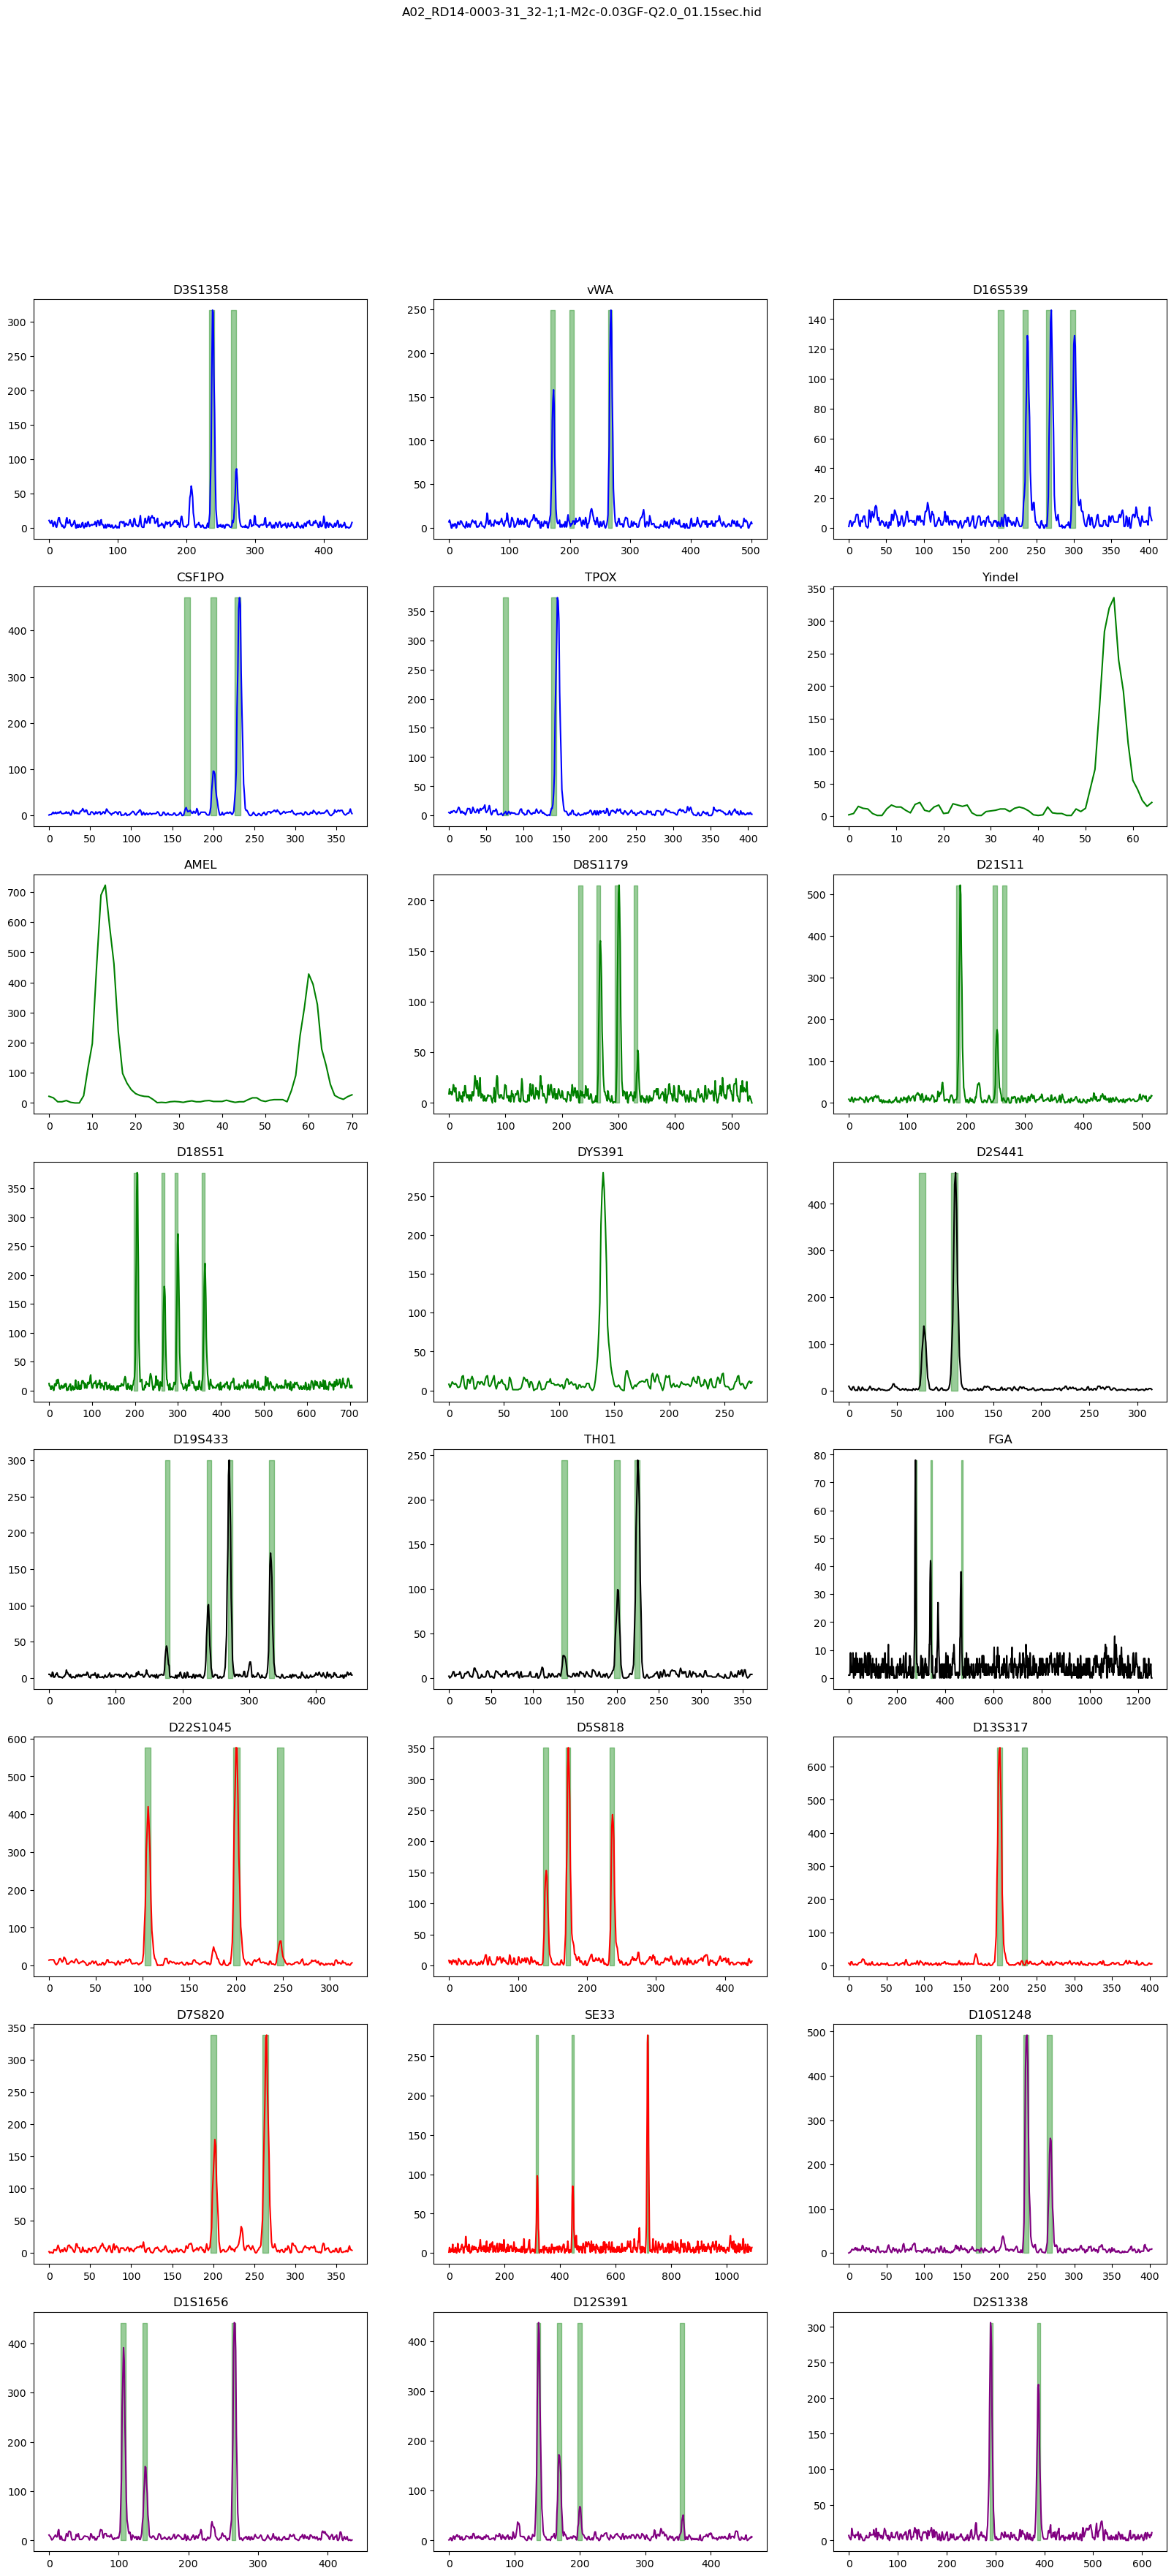

In [12]:
# plot_profile(hid_images=[image])
plot_profile_markers(hid_images=[image])

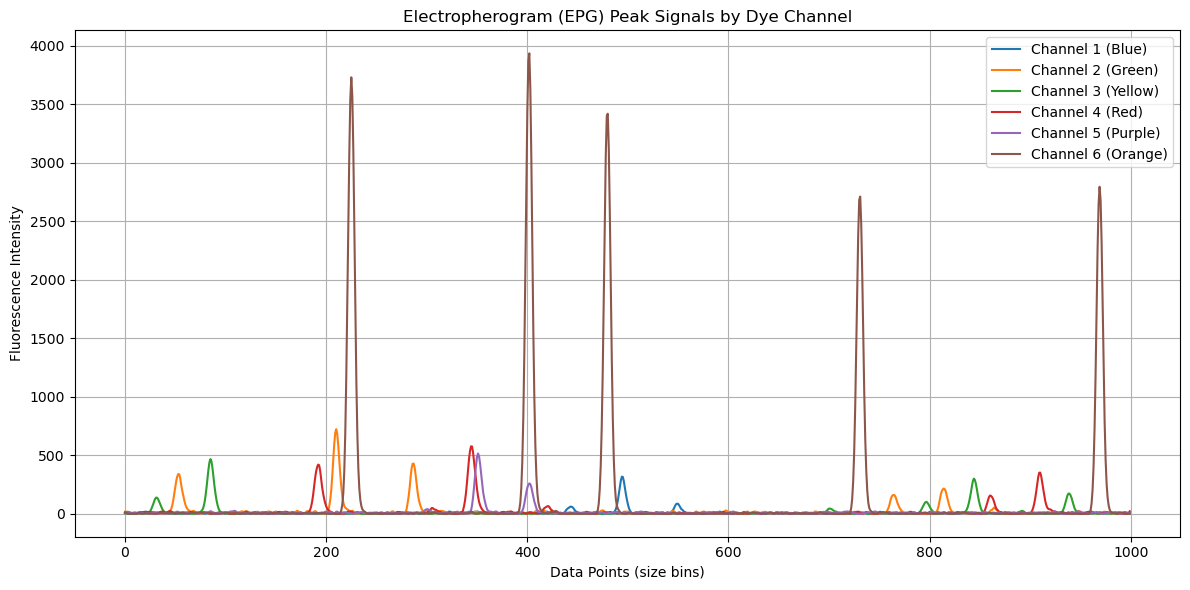

In [34]:
epg = get_peak_data(image.path)[:, 4000:5000] # original shape: (6, 9641)

def plot_epg_together(epg):
    plt.figure(figsize=(12, 6))
    dye_labels = ['Blue', 'Green', 'Yellow', 'Red', 'Purple', 'Orange']  # Optional: adjust per your kit

    for i in range(epg.shape[0]):
        plt.plot(epg[i], label=f'Channel {i+1} ({dye_labels[i]})')

    plt.xlabel("Data Points (size bins)")
    plt.ylabel("Fluorescence Intensity")
    plt.title("Electropherogram (EPG) Peak Signals by Dye Channel")
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()

plot_epg_together(epg)
# # plot_epg_together(annotation_image_mock_data)

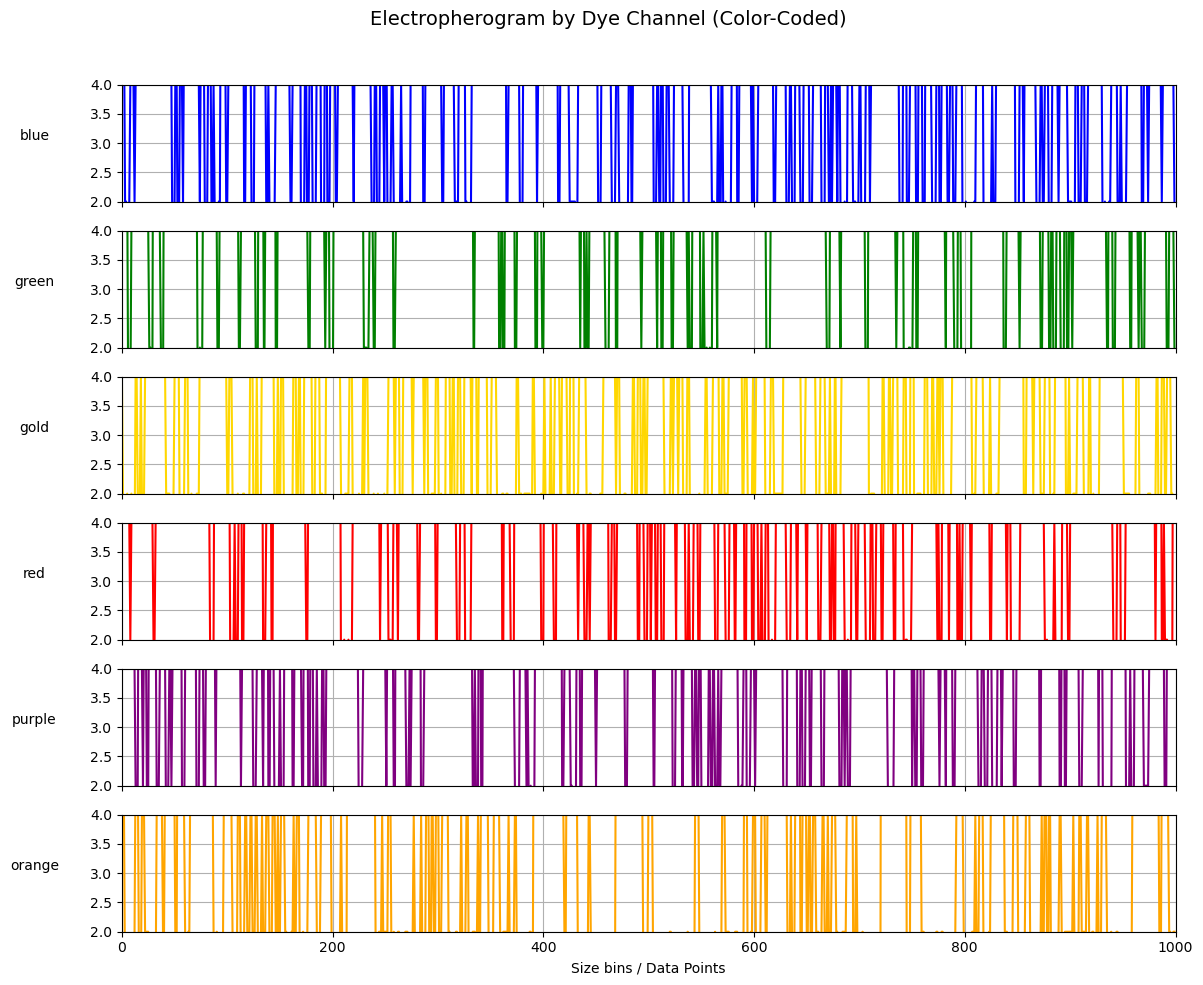

In [25]:
dye_colors = ['blue', 'green', 'gold', 'red', 'purple', 'orange']

fig, axs = plt.subplots(6, 1, figsize=(12, 10), sharex=True)

for i in range(6):
    axs[i].plot(epg[i], color=dye_colors[i])
    axs[i].set_ylabel(dye_colors[i], rotation=0, labelpad=40, fontsize=10)
    axs[i].grid(True)
    axs[i].set_xlim(0, epg.shape[1])
    axs[i].set_ylim(2, 4)  # Adjust y-limits for better visibility

axs[-1].set_xlabel("Size bins / Data Points")
plt.suptitle("Electropherogram by Dye Channel (Color-Coded)", fontsize=14)
plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()


In [33]:
# count the different values in the epg array
unique, counts = np.unique(epg, return_counts=True)
# print(dict(zip(unique, counts)))
list(zip(unique, counts))[:30], unique[:20]

([(0, 385),
  (1, 722),
  (2, 860),
  (4, 802),
  (5, 648),
  (7, 511),
  (8, 427),
  (9, 301),
  (11, 247),
  (12, 176),
  (14, 126),
  (15, 100),
  (17, 84),
  (18, 54),
  (19, 30),
  (21, 22),
  (22, 26),
  (24, 18),
  (25, 18),
  (27, 14),
  (28, 10),
  (29, 7),
  (31, 2),
  (32, 10),
  (34, 5),
  (35, 6),
  (37, 9),
  (38, 10),
  (39, 4),
  (41, 6)],
 array([ 0,  1,  2,  4,  5,  7,  8,  9, 11, 12, 14, 15, 17, 18, 19, 21, 22,
        24, 25, 27], dtype=int16))